# 04 · Event study — aligned windows around events

Each event gets a window of ±N days, plotted on a common **"days from event"**
axis so events are directly comparable. Two readouts per event: the **net stance
index** and the **conversation volume**.

The second half is built for **you**: drop your own outlier dates into
`CUSTOM_EVENTS` and re-run — the same machinery plots them at whatever grain you
choose. Great for the dates the day-part teammate flags.

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
sh = A.add_geo(A.load_rollup("stance_hourly"))

def window_series(center, window_days=60, grain="daily", geo_tier=None):
    """On-topic net index + volume in a +/- window around `center`, indexed by days-from-event."""
    center = pd.Timestamp(center)
    df = sh if geo_tier is None else sh[sh.geo_tier==geo_tier]
    lo, hi = center - pd.Timedelta(days=window_days), center + pd.Timedelta(days=window_days)
    d = df[(df.et_date>=lo)&(df.et_date<=hi)]
    agg = A.aggregate(d, grain, by=(), stance_col="stance")
    wide = A.stance_shares(agg, index_cols=["period"]).sort_values("period")
    wide["days_from_event"] = (wide.period - center).dt.days
    return wide

def plot_event(center, label, window_days=60, grain="daily", ax=None, geo_tier=None):
    w = window_series(center, window_days, grain, geo_tier)
    if ax is None: _, ax = plt.subplots()
    ax.axvline(0, color=C.PALETTE["terracotta"], ls="--", lw=1.5)
    ax.axhline(0, color="#9AA7AB", lw=0.8)
    ax.plot(w.days_from_event, w.net, color=C.PALETTE["deep_teal"], lw=1.6, marker="o", ms=3)
    ax.set_title(f"{label}  (±{window_days}d, {grain})", fontsize=10)
    ax.set_xlabel("days from event"); ax.set_ylabel("net stance")
    return ax

### Canonical events — net stance in a ±60-day window

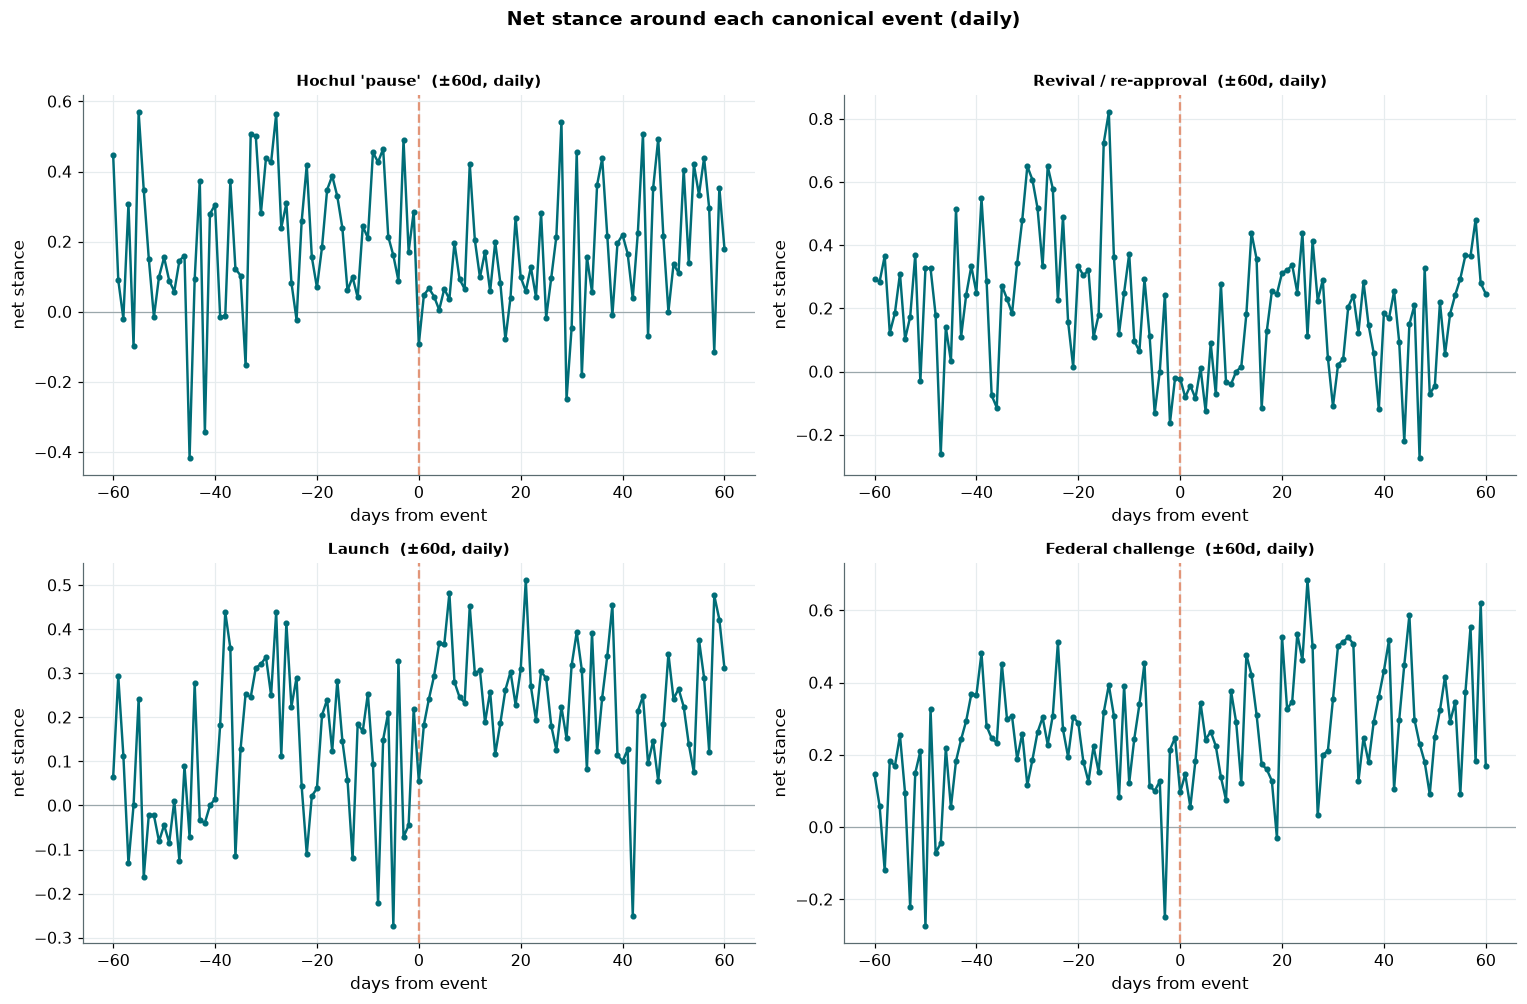

In [3]:
ev = [e for e in C.EVENTS]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, e in zip(axes.ravel(), ev):
    plot_event(e["date"], e["label"], window_days=60, grain="daily", ax=ax)
for ax in axes.ravel()[len(ev):]: ax.axis("off")
fig.suptitle("Net stance around each canonical event (daily)", y=1.01, fontweight="bold")
plt.tight_layout(); plt.show()

### Volume around events (same windows)

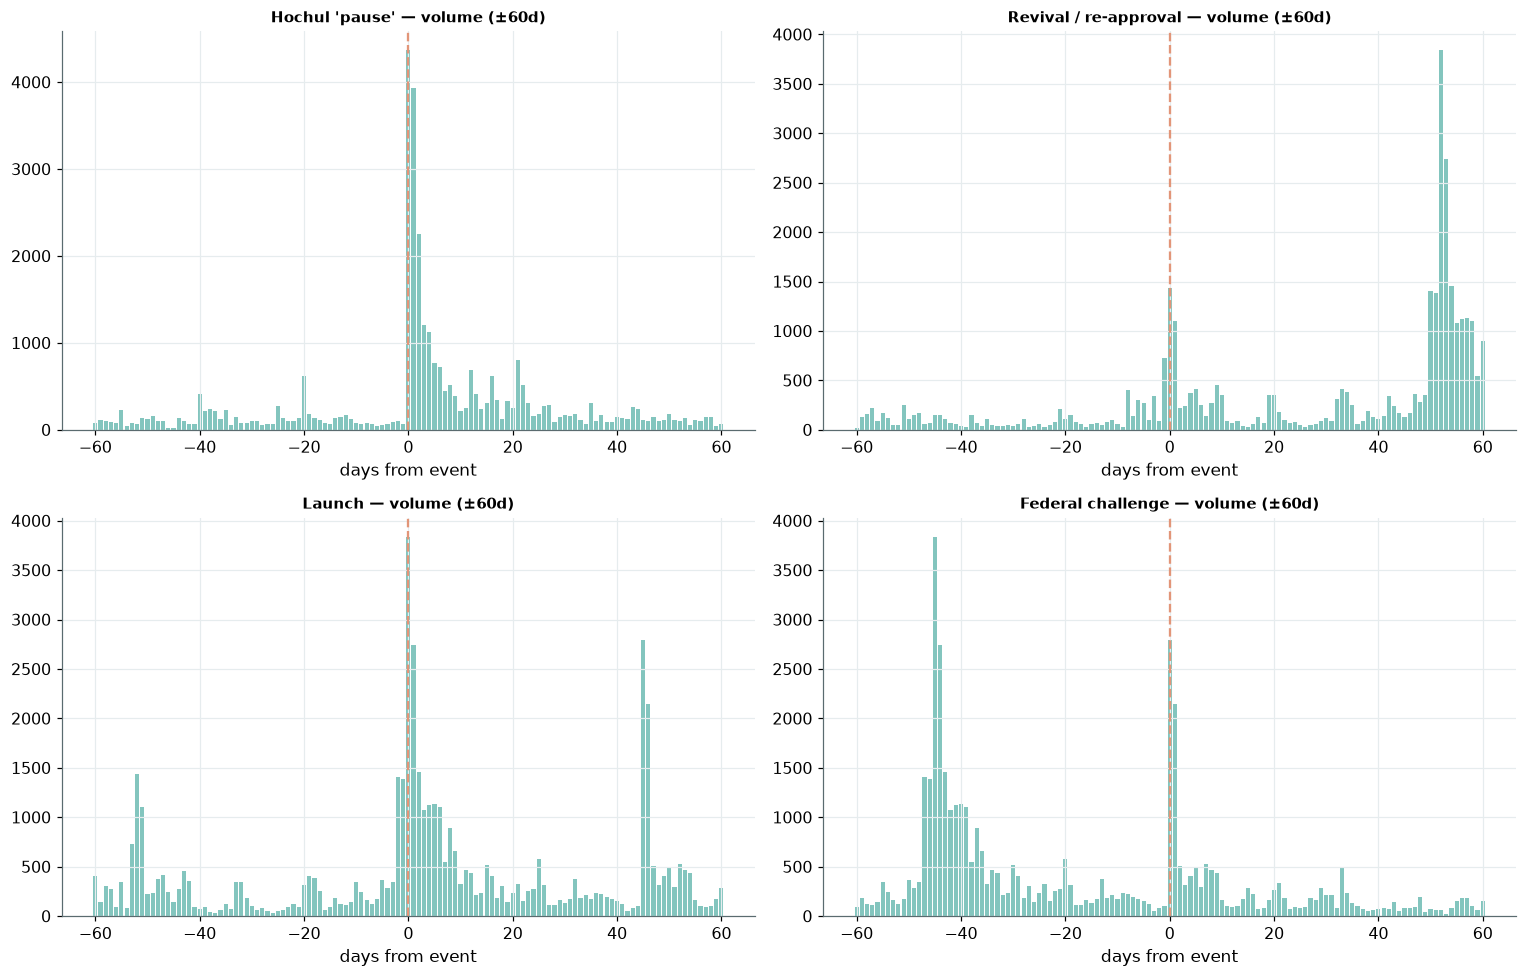

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, e in zip(axes.ravel(), ev):
    w = window_series(e["date"], 60, "daily")
    ax.axvline(0, color=C.PALETTE["terracotta"], ls="--", lw=1.5)
    ax.bar(w.days_from_event, w.n_total, color=C.PALETTE["teal"])
    ax.set_title(f"{e['label']} — volume (±60d)", fontsize=10); ax.set_xlabel("days from event")
for ax in axes.ravel()[len(ev):]: ax.axis("off")
plt.tight_layout(); plt.show()

---
## ✏️ YOUR EVENTS — edit this section

Add outlier dates your teammate finds. Each entry: `("YYYY-MM-DD", "label")`.
Change `WINDOW` / `GRAIN` to zoom. Re-run the two cells below; nothing above
changes. (Grain `daily` is best for tight windows; `weekly` smooths a noisy one.)

In [5]:
CUSTOM_EVENTS = [
    # ("2025-03-15", "example outlier — replace me"),
]
WINDOW = 45        # +/- days
GRAIN  = "daily"   # "daily" | "weekly" | "monthly"
GEO    = None      # e.g. "Manhattan core" to restrict, or None for all

In [6]:
if not CUSTOM_EVENTS:
    print("No custom events yet — add some to CUSTOM_EVENTS above and re-run.")
else:
    n = len(CUSTOM_EVENTS); ncol = min(2, n); nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(7*ncol, 4*nrow), squeeze=False)
    for ax, (date,label) in zip(axes.ravel(), CUSTOM_EVENTS):
        plot_event(date, label, window_days=WINDOW, grain=GRAIN, ax=ax, geo_tier=GEO)
    for ax in axes.ravel()[n:]: ax.axis("off")
    fig.suptitle(f"Custom events ({GRAIN}, ±{WINDOW}d, geo={GEO or 'all'})", y=1.01, fontweight="bold")
    plt.tight_layout(); plt.show()

No custom events yet — add some to CUSTOM_EVENTS above and re-run.


Tip: to compare an event across geographies, loop `GEO` over `C.GEO_TIER_ORDER` and call `plot_event` per tier.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>